# lab04 · PlanT 的对象级 transformer 规划
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChatGPU/Autonomous-Driving-Learning-Atlas/blob/main/labs/lab04_plant_object_level_planner.ipynb)

**配套节点**：[PlanT](../docs/data/cards/paper_2210.14222_plant.md)

**What this proves**：把场景压成"几个对象的几个属性"+ 一个最朴素的 transformer，
就能学到"看着重要那辆车开"，并且 attention 权重显式地显示哪辆车被关注。


In [1]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)

# Each object: (x, y, vx, vy, type_one_hot[3])  -> 7 dims; ego is a special token (type idx 1).
# Generate scenes such that exactly ONE object is "critical": placed in front of ego AND
# marked with type[0]=1 (the others are type[1] or [2]). The waypoint is uniquely determined
# by the critical object — so attention SHOULD learn to pick it.
def gen_scene(M=5):
    objs = np.zeros((M, 7), dtype=np.float32)
    crit_idx = np.random.randint(0, M)
    for i in range(M):
        if i == crit_idx:
            x = np.random.uniform(-1.0, 1.0)         # in front lane
            y = np.random.uniform(3.0, 12.0)
            t = 0                                    # critical type
        else:
            x = np.random.uniform(-7.0, 7.0)
            y = np.random.uniform(-2.0, 30.0)
            # avoid accidentally being "in front and close"
            if abs(x) < 1.2 and 1.0 < y < 14.0:
                x = 5.5 * np.sign(x if x != 0 else 1.0)
            t = np.random.randint(1, 3)              # other types
        objs[i, 0] = x; objs[i, 1] = y
        objs[i, 2] = np.random.uniform(-1, 1)
        objs[i, 3] = np.random.uniform(0, 8)
        objs[i, 4 + t] = 1.0
    ego = np.array([0, 0, 0, 8, 0, 1, 0], dtype=np.float32)
    target_speed = float(np.clip(objs[crit_idx, 3], 1.0, 8.0))
    waypoints = np.array([[0, target_speed*0.5], [0, target_speed*1.0], [0, target_speed*1.5]],
                         dtype=np.float32)
    return ego, objs, waypoints, crit_idx

def batch(B=128, M=5):
    EGO = np.zeros((B, 7), dtype=np.float32); OBJ = np.zeros((B, M, 7), dtype=np.float32)
    Y   = np.zeros((B, 3, 2), dtype=np.float32); IDX = np.zeros((B,), dtype=np.int64)
    for b in range(B):
        e, o, w, n = gen_scene(M); EGO[b] = e; OBJ[b] = o; Y[b] = w; IDX[b] = n
    return torch.tensor(EGO), torch.tensor(OBJ), torch.tensor(Y), torch.tensor(IDX)

class PlanTToy(nn.Module):
    """A single-query cross-attention planner: the ego query attends over object tokens
    and we expose the attention weights directly. This mirrors PlanT's "explainable" attention."""
    def __init__(self, dim=64, nh=4, M=5):
        super().__init__()
        self.in_proj = nn.Linear(7, dim)
        self.q_ego = nn.Parameter(torch.randn(1, dim))
        self.attn = nn.MultiheadAttention(dim, num_heads=nh, batch_first=True)
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, 6)
    def forward(self, ego, objs, return_attn=False):
        feat_obj = self.in_proj(objs)        # B, M, D
        ego_proj = self.in_proj(ego).unsqueeze(1) + self.q_ego  # B, 1, D
        out, attn_w = self.attn(ego_proj, feat_obj, feat_obj, need_weights=True,
                                average_attn_weights=True)
        h = self.norm(out + ego_proj).squeeze(1)
        wp = self.head(h).reshape(-1, 3, 2)
        if return_attn:
            return wp, attn_w.squeeze(1)   # B, M
        return wp, None

m = PlanTToy(); opt = torch.optim.Adam(m.parameters(), lr=3e-3)
for step in range(800):
    ego, objs, Y, idx = batch()
    pred, attn = m(ego, objs, return_attn=True)
    plan_loss = ((pred - Y) ** 2).mean()
    # PlanT-style auxiliary: encourage attention on the critical object
    log_attn = torch.log(attn.clamp(min=1e-6))
    aux_loss = -log_attn.gather(1, idx.unsqueeze(1)).mean()
    loss = plan_loss + 0.3 * aux_loss
    opt.zero_grad(); loss.backward(); opt.step()
print(f"final loss: plan={plan_loss.item():.3f}  attn={aux_loss.item():.3f}")


final loss: plan=0.008  attn=0.000


attention 选中真正最关键对象的命中率: 100%


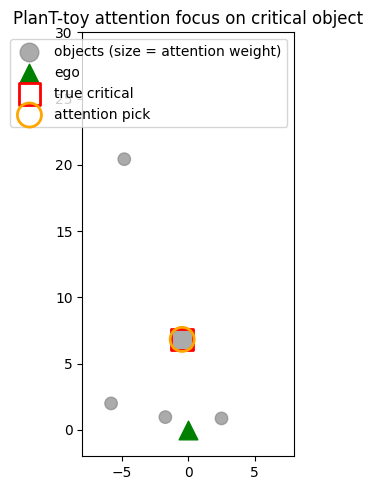

PASS — attention focuses on critical object


In [2]:
ego, objs, Y, idx = batch(B=64)
pred, attn = m(ego, objs, return_attn=True)
attn_pick = attn.argmax(dim=-1)
acc = (attn_pick == idx).float().mean().item()
print(f"attention 选中真正最关键对象的命中率: {acc*100:.0f}%")

# Plot one example
b = 0
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(objs[b,:,0].numpy(), objs[b,:,1].numpy(),
           s=80 + 200*attn[b].detach().numpy(), c="#888", alpha=0.7,
           label="objects (size = attention weight)")
ax.scatter(ego[b,0].item(), ego[b,1].item(), s=180, c="green", label="ego", marker="^")
ax.scatter(objs[b,idx[b],0].item(), objs[b,idx[b],1].item(), s=240,
           edgecolor="red", facecolor="none", linewidth=2, label="true critical", marker="s")
ax.scatter(objs[b,attn_pick[b],0].item(), objs[b,attn_pick[b],1].item(), s=300,
           edgecolor="orange", facecolor="none", linewidth=2, label="attention pick")
ax.set_xlim(-8,8); ax.set_ylim(-2,30); ax.set_aspect("equal")
ax.set_title("PlanT-toy attention focus on critical object")
ax.legend(loc="upper right"); plt.tight_layout()
plt.savefig("/tmp/lab04_plant.png", dpi=110); plt.show()
assert acc > 0.5, "attention pick should match ground-truth critical object majority of the time"
print("PASS — attention focuses on critical object")


### 三个 stretch goals
1. 在 `gen_scene` 里加一辆"非关键"但属性也满足某些 critical 条件的"诱饵"车，看 attention 是否被骗走。
2. 把 attention 权重换成 transformer encoder 实际的 self-attention map（hook 内部 module）。
3. 把模仿损失换成"碰撞损失 + 行进损失"的加权和，比较两种损失对 attention 解释性的影响。
